# Test Model and Atlas Inititiation

## Setup

In [36]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from aligner.models import EmbryoFrame, ReferenceFrame
from aligner.atlas import StaticGaussianAtlas
from aligner.inventory import SliceAtlas

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Atlas Load

In [39]:
# Initialize the libraries
gauss_atlas = StaticGaussianAtlas("/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/label_position_gaussians.csv")
slice_db = SliceAtlas("/Users/miles/Documents/UCLA/shah_lab/embryo_aligner/data/processed/atlas/lineage_slice_frequencies.csv")



In [49]:
# Test 1: Check slice retrieval for an 8-cell embryo
n_obs = 6
candidates = slice_db.get_candidates(n_obs)
print(f"Found {len(candidates)} biological hypotheses for {n_obs} cells.")

candidates

Found 1 biological hypotheses for 6 cells.


[('ABal', 'ABar', 'ABpl', 'ABpr', 'EMS', 'P2')]

In [50]:
# Test 2: Verify the Gaussian lookup for the first candidate
sample_labels = candidates[0]
ref_mus, ref_invs = gauss_atlas.get_params(list(sample_labels))
print(f"Successfully retrieved {len(ref_mus)} means from the Gaussian Atlas.")

ref_mus
ref_invs

Successfully retrieved 6 means from the Gaussian Atlas.


[array([[106.01212615, -47.23509388,  71.83733171],
        [-47.23509388, 280.54934245,  77.61154764],
        [ 71.83733171,  77.61154764, 335.99743047]]),
 array([[ 233.54526076, -133.98220825,  177.25016177],
        [-133.98220825,  108.05324393,  -89.84238071],
        [ 177.25016177,  -89.84238071,  250.8848418 ]]),
 array([[ 234.47433636, -135.54252506,   57.74448431],
        [-135.54252506,   94.79040893,  -53.11649824],
        [  57.74448431,  -53.11649824,  113.14193178]]),
 array([[119.67712608, -38.62397671, -47.16068174],
        [-38.62397671, 185.82421627,  64.83716023],
        [-47.16068174,  64.83716023, 101.93213013]]),
 array([[ 349.22562733, -134.14777571,   25.56032662],
        [-134.14777571,  212.84252465,  -79.45560774],
        [  25.56032662,  -79.45560774,  144.63794128]]),
 array([[257.89635606, -27.38784029, 127.00411961],
        [-27.38784029, 105.57004574, -25.12638242],
        [127.00411961, -25.12638242, 569.61688692]])]

In [51]:
# Create the schematic model for the first hypothesis
hypothetical_embryo = ReferenceFrame(sample_labels, gauss_atlas)

print(f"Labels: {hypothetical_embryo.labels[:4]}...")
print(f"Centered Means Shape: {hypothetical_embryo.centered_means.shape}")
print(f"Principal Axis (PC1): {hypothetical_embryo.pc1_axis}")

# Sanity Check: The center of mass should be at [0, 0, 0]
com = hypothetical_embryo.centered_means.mean(axis=0)
print(f"Center of Mass: {com}") # Should be near zero

Labels: ('ABal', 'ABar', 'ABpl', 'ABpr')...
Centered Means Shape: (6, 3)
Principal Axis (PC1): [-0.98384916  0.16260285 -0.0748408 ]
Center of Mass: [-2.40548322e-16  3.70074342e-17  1.48029737e-16]


## Embryo Test

In [52]:
# Let's just use the reference means + some noise and a shift
raw_coords = ref_mus * 1.2 + np.random.normal(0, 5, size=ref_mus.shape) + 100

# Initialize the Model
frame = EmbryoFrame(coords=raw_coords, embryo_id="TEST_01", time_idx=1)

print(f"Before Prepare: Mean = {frame.coords.mean(axis=0)}")
print(f"Before Prepare: Scale = {frame.scale_factor}")

# Run the logic we wrote
frame.prepare()

print(f"After Prepare: Mean = {frame.normalized_coords.mean(axis=0)}") # Should be near [0,0,0]
print(f"After Prepare: Scale = {frame.scale_factor}")

frame

Before Prepare: Mean = [ 99.90600793 104.19052456 100.92712303]
Before Prepare: Scale = 1.0
After Prepare: Mean = [ 5.92118946e-16  5.92118946e-16 -1.03620816e-15]
After Prepare: Scale = 11.798428215179218


EmbryoFrame(ID=TEST_01, T=1, N=6)

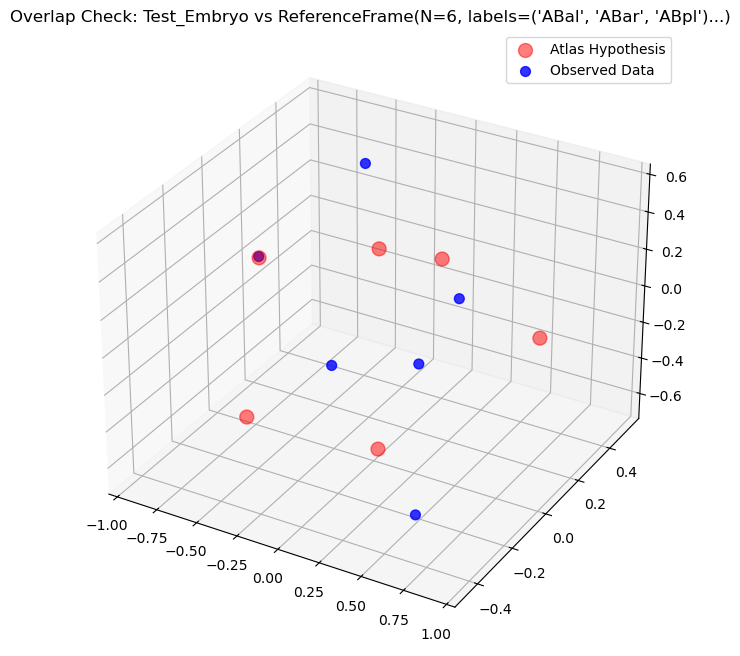

In [62]:

# Initialize and prepare your observed data
obs_frame = EmbryoFrame(raw_coords, "Test_Embryo", 1)
obs_frame.prepare()

# Plot them together
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Schematic (Red)
ax.scatter(hypothetical_embryo.centered_means[:, 0], 
           hypothetical_embryo.centered_means[:, 1], 
           hypothetical_embryo.centered_means[:, 2], 
           color='red', s=100, label='Atlas Hypothesis', alpha=0.5)

# Plot Observed (Blue)
ax.scatter(obs_frame.normalized_coords[:, 0], 
           obs_frame.normalized_coords[:, 1], 
           obs_frame.normalized_coords[:, 2], 
           color='blue', s=50, label='Observed Data', alpha=0.8)

ax.set_title(f"Overlap Check: {obs_frame.embryo_id} vs {hypothetical_embryo}")
ax.legend()
plt.show()

In [57]:
obs_frame


EmbryoFrame(ID=Test_Embryo, T=1, N=6)

In [58]:
hypothetical_embryo

ReferenceFrame(N=6, labels=('ABal', 'ABar', 'ABpl')...)

In [59]:
obs_frame.normalized_coords

array([[ 0.62167979, -0.10711199,  0.39165372],
       [ 0.33946125, -0.06087513, -0.06347126],
       [-0.33276757,  0.06450438, -0.35446946],
       [ 0.53341146, -0.25830458, -0.65378709],
       [-0.35844222,  0.28281209,  0.56486769],
       [-0.8033427 ,  0.07897523,  0.1152064 ]])

In [63]:
hypothetical_embryo.centered_means

array([[ 9.14935445e-01,  7.36483526e-02,  1.10016922e-01],
       [ 5.22889827e-01, -4.56114299e-01, -1.19608620e-01],
       [ 3.11465954e-03,  2.83235798e-02,  3.91604855e-01],
       [-3.93346111e-01, -3.43818528e-01, -2.99549878e-01],
       [-1.27044723e-01,  5.18741475e-01, -8.28202635e-02],
       [-9.20549097e-01,  1.79219419e-01,  3.56983077e-04]])

In [68]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from typing import Tuple
coords_a = obs_frame.normalized_coords
coords_b = hypothetical_embryo.centered_means

C = cdist(coords_a, coords_b, metric = "sqeuclidean")

out = linear_sum_assignment(C)
out

(array([0, 1, 2, 3, 4, 5]), array([0, 4, 3, 1, 2, 5]))

In [69]:
from aligner.matcher import HungarianMatcher

# 1. Setup
matcher = HungarianMatcher()
obs_pts = frame.normalized_coords
ref_pts = hypothetical_embryo.centered_means

# 2. Run Matcher
row_idx, col_idx = matcher.match(obs_pts, ref_pts)

# 3. Verify
for i in range(len(row_idx)):
    print(f"Observed Cell {row_idx[i]} matched to Atlas Label: {hypothetical_embryo.labels[col_idx[i]]}")

Observed Cell 0 matched to Atlas Label: ABal
Observed Cell 1 matched to Atlas Label: EMS
Observed Cell 2 matched to Atlas Label: ABpr
Observed Cell 3 matched to Atlas Label: ABar
Observed Cell 4 matched to Atlas Label: ABpl
Observed Cell 5 matched to Atlas Label: P2


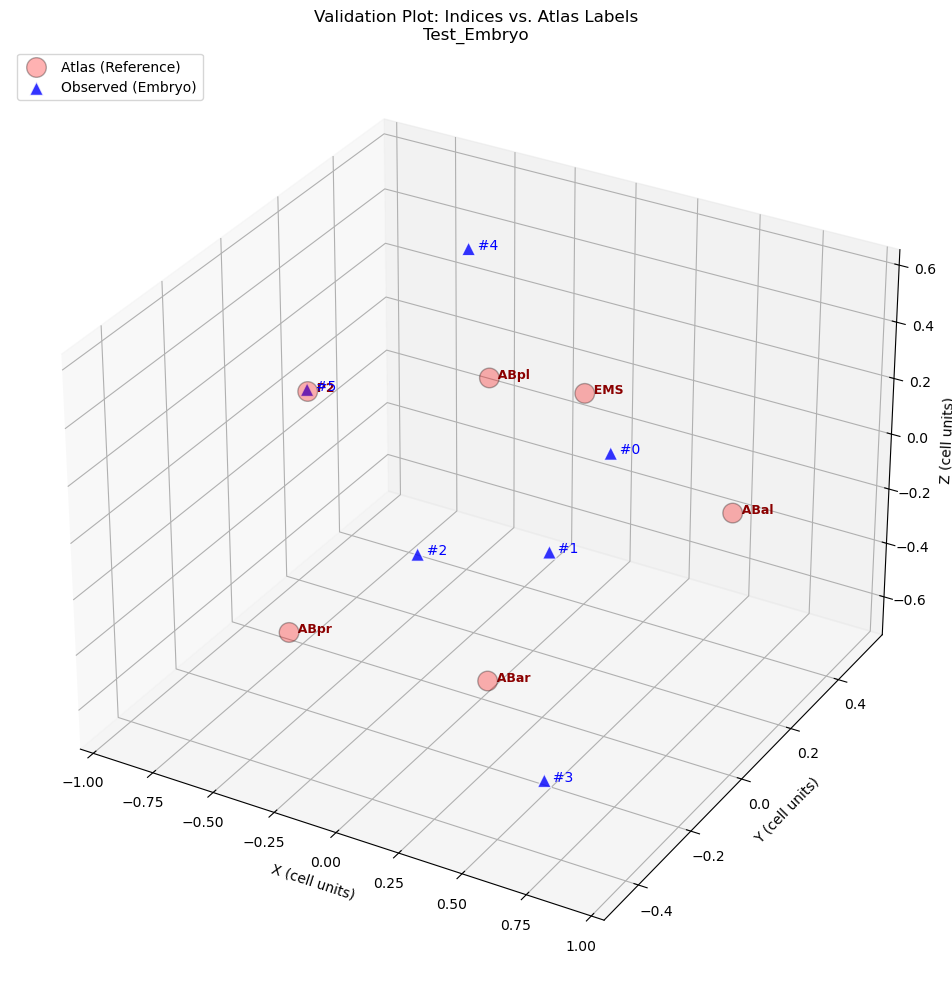

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 2. Plot Atlas (Schematic Reference)
# Using circles 'o' as the reference points
atlas_pts = hypothetical_embryo.centered_means
atlas_labels = hypothetical_embryo.labels

ax.scatter(atlas_pts[:, 0], atlas_pts[:, 1], atlas_pts[:, 2], 
           color='red', marker='o', s=200, edgecolors='black', 
           alpha=0.3, label='Atlas (Reference)')

# Add biological names next to Atlas points
for i, name in enumerate(atlas_labels):
    ax.text(atlas_pts[i, 0], atlas_pts[i, 1], atlas_pts[i, 2], 
            f"  {name}", color='darkred', fontsize=9, fontweight='bold')

# 3. Plot Observed Data (Experimental)
# Using triangles '^' as the experimental points
obs_pts = obs_frame.normalized_coords #@ R

ax.scatter(obs_pts[:, 0], obs_pts[:, 1], obs_pts[:, 2], 
           color='blue', marker='^', s=100, edgecolors='white', 
           alpha=0.8, label='Observed (Embryo)')

# Add numerical indices next to Observed points
for i in range(len(obs_pts)):
    ax.text(obs_pts[i, 0], obs_pts[i, 1], obs_pts[i, 2], 
            f"  #{i}", color='blue', fontsize=10)

# 4. Final touches
ax.set_title(f"Validation Plot: Indices vs. Atlas Labels\n{obs_frame.embryo_id}")
ax.set_xlabel('X (cell units)')
ax.set_ylabel('Y (cell units)')
ax.set_zlabel('Z (cell units)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

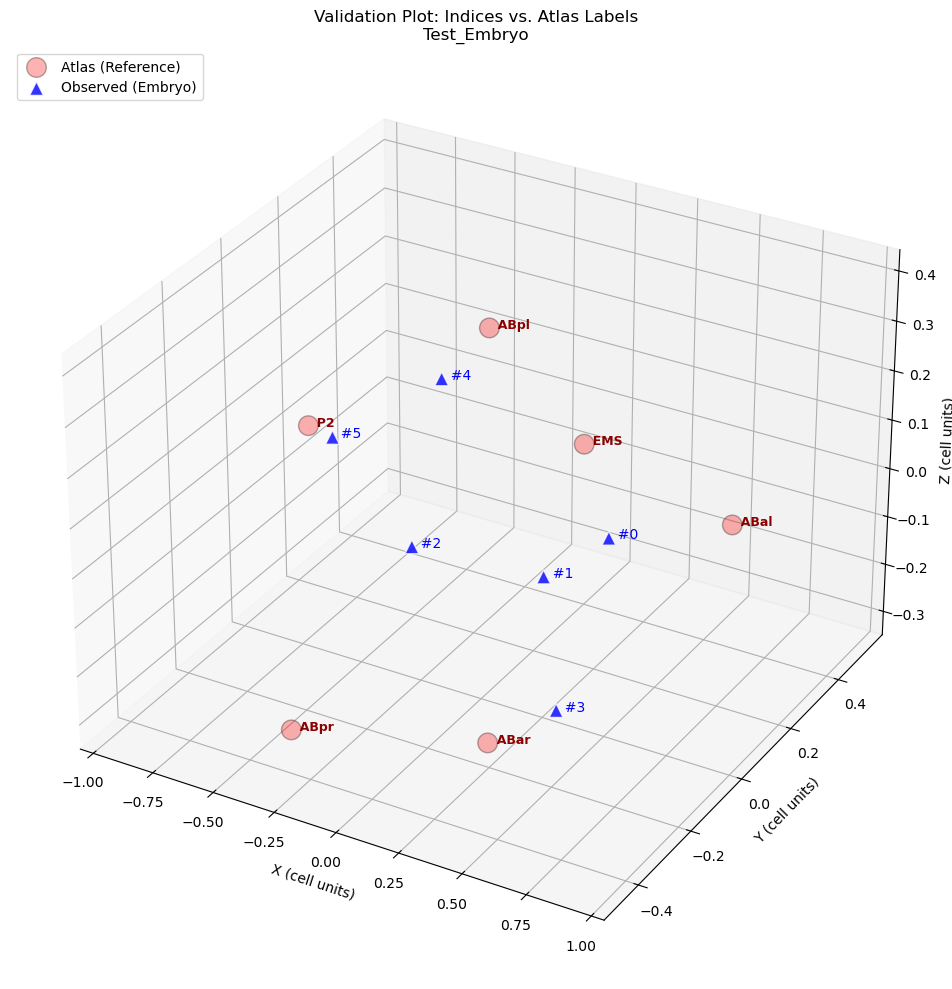

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 2. Plot Atlas (Schematic Reference)
# Using circles 'o' as the reference points
atlas_pts = hypothetical_embryo.centered_means #@ R
atlas_labels = hypothetical_embryo.labels

ax.scatter(atlas_pts[:, 0], atlas_pts[:, 1], atlas_pts[:, 2], 
           color='red', marker='o', s=200, edgecolors='black', 
           alpha=0.3, label='Atlas (Reference)')

# Add biological names next to Atlas points
for i, name in enumerate(atlas_labels):
    ax.text(atlas_pts[i, 0], atlas_pts[i, 1], atlas_pts[i, 2], 
            f"  {name}", color='darkred', fontsize=9, fontweight='bold')

# 3. Plot Observed Data (Experimental)
# Using triangles '^' as the experimental points
obs_pts = obs_frame.normalized_coords @ R

ax.scatter(obs_pts[:, 0], obs_pts[:, 1], obs_pts[:, 2], 
           color='blue', marker='^', s=100, edgecolors='white', 
           alpha=0.8, label='Observed (Embryo)')

# Add numerical indices next to Observed points
for i in range(len(obs_pts)):
    ax.text(obs_pts[i, 0], obs_pts[i, 1], obs_pts[i, 2], 
            f"  #{i}", color='blue', fontsize=10)

# 4. Final touches
ax.set_title(f"Validation Plot: Indices vs. Atlas Labels\n{obs_frame.embryo_id}")
ax.set_xlabel('X (cell units)')
ax.set_ylabel('Y (cell units)')
ax.set_zlabel('Z (cell units)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [78]:
import numpy as np
ccv = obs_pts.T @ ref_pts
#ccv

U, S, Vh = np.linalg.svd(ccv)

In [83]:
U


array([[-0.98382855,  0.02762367, -0.17696983],
       [ 0.16368023, -0.26256068, -0.95093147],
       [-0.07273354, -0.96452   ,  0.25379325]])

In [84]:
Vh

array([[-0.89669055,  0.41377514,  0.1572774 ],
       [-0.43286168, -0.89396826, -0.11598068],
       [-0.09261108,  0.17207814, -0.9807203 ]])

In [88]:
np.linalg.det(Vh.T @ U.T)

np.float64(0.9999999999999999)

In [86]:
Vh[-1, :] *= -1

In [87]:
Vh

array([[-0.89669055,  0.41377514,  0.1572774 ],
       [-0.43286168, -0.89396826, -0.11598068],
       [ 0.09261108, -0.17207814,  0.9807203 ]])

In [89]:
R = Vh.T * U.T

In [90]:
R

array([[ 0.88218977, -0.0708509 , -0.00673593],
       [ 0.01142999,  0.23472091,  0.16597281],
       [-0.02783335,  0.11028968,  0.24890019]])